In [1]:
import pandas as pd
import seaborn as sns

ads = pd.read_csv("Social_Network_Ads.csv")

ads.head(3)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0


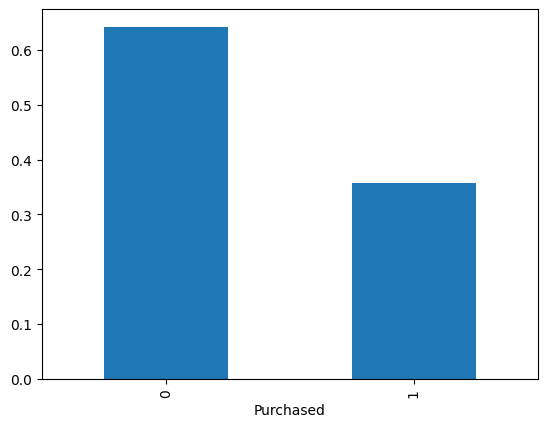

In [2]:
# Explore the target
ads["Purchased"].value_counts(normalize=True).plot.bar();

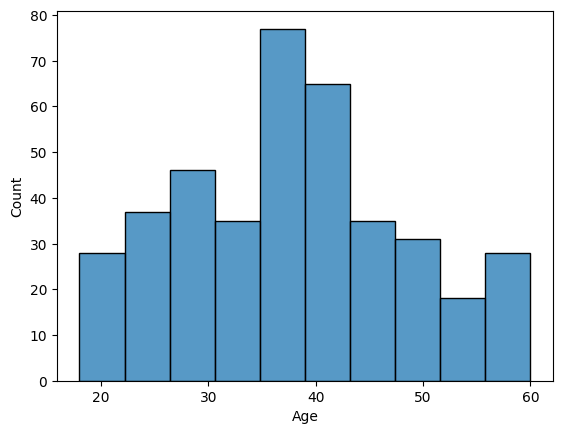

In [3]:
# explore the features

sns.histplot(ads["Age"]);

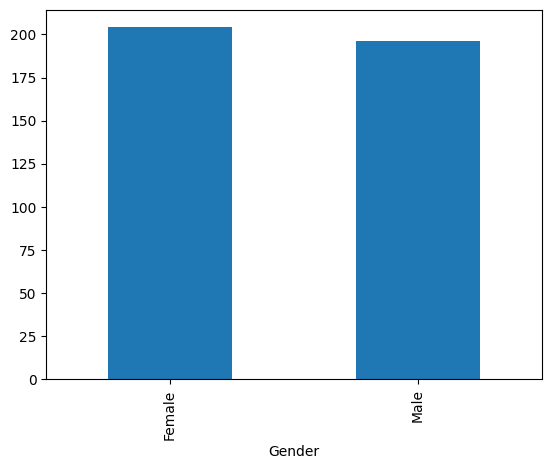

In [4]:
ads["Gender"].value_counts().plot.bar();

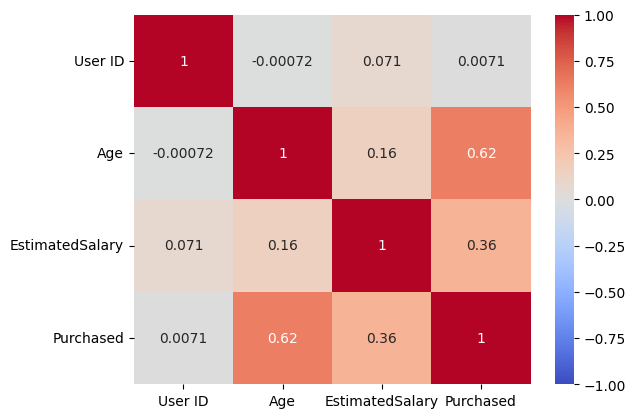

In [5]:
# coreelation matrix

sns.heatmap(
    ads.corr(numeric_only=True),
    vmin = -1,
    vmax = 1,
    cmap="coolwarm",
    annot=True
);

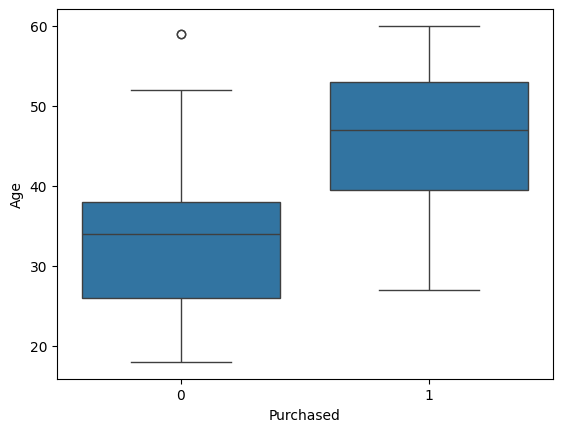

In [6]:
sns.boxplot(ads, x="Purchased", y="Age");

In [7]:
ads.groupby("Purchased")["Age"].mean()

Purchased
0    32.793774
1    46.391608
Name: Age, dtype: float64

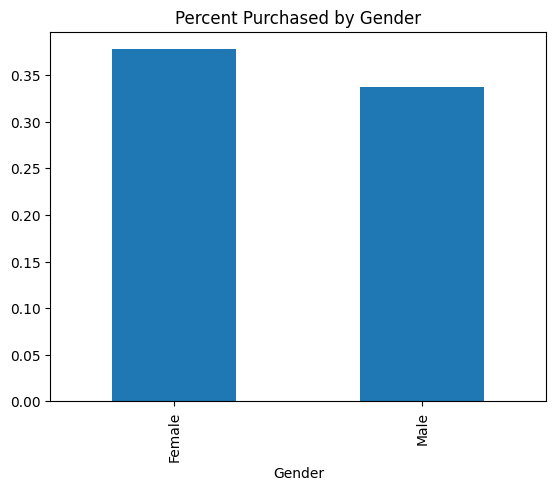

In [8]:
(ads
 .groupby("Gender")
 .agg({"Purchased": "mean"})
 .plot
 .bar(title="Percent Purchased by Gender", legend=False)
);

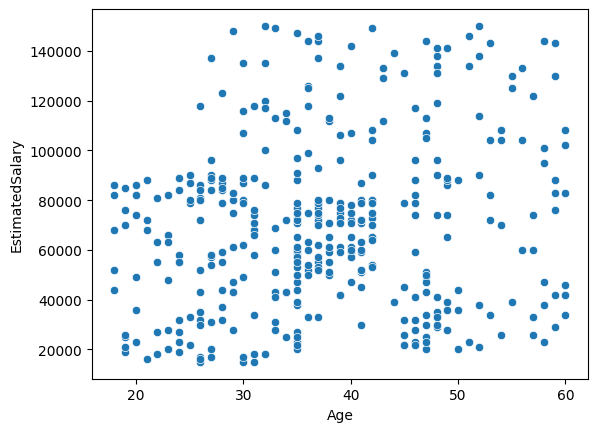

In [9]:
# Feature Feature relationsgips

sns.scatterplot(ads, x="Age", y="EstimatedSalary");

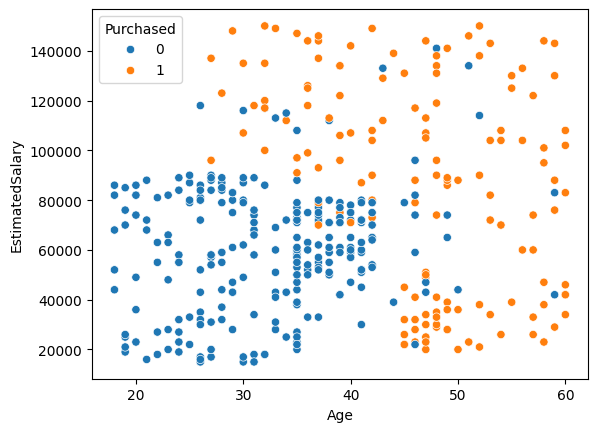

In [10]:
sns.scatterplot(data=ads, x="Age", y="EstimatedSalary", hue="Purchased");

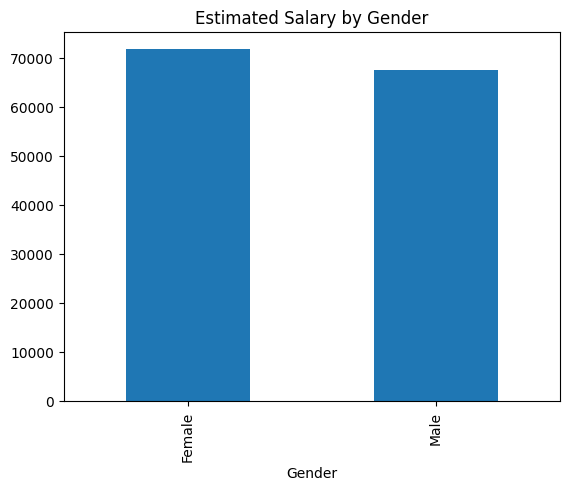

In [11]:
(ads
 .groupby("Gender")
 .agg({"EstimatedSalary": "mean"})
 .plot
 .bar(title="Estimated Salary by Gender", legend=False)
);

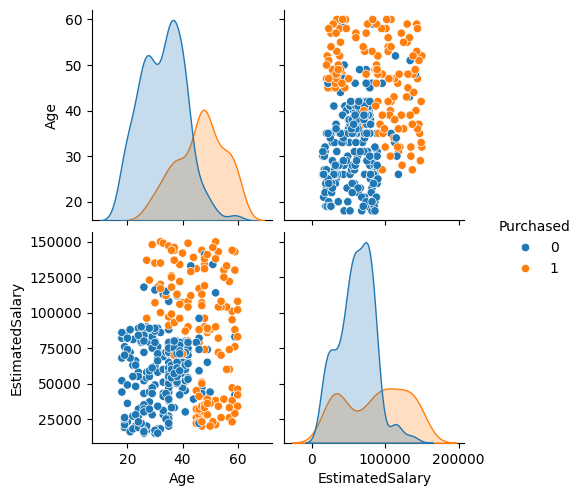

In [12]:
# pairplot 

sns.pairplot(ads.drop("User ID", axis=1), hue="Purchased");

## Feature Engineering

In [13]:
import numpy as np

ads = pd.get_dummies(
    ads.assign(
        age45 = np.where(ads["Age"] > 45, 1, 0),
        salary90 = np.where(ads["EstimatedSalary"] > 90000, 1, 0),
        agexsal = ads["Age"] * ads["EstimatedSalary"]
    ),
    drop_first=True
)
ads.head()

,User ID,Age,EstimatedSalary,Purchased,age45,salary90,agexsal,Gender_Male
0,15624510,19,19000,0,0,0,361000,True
1,15810944,35,20000,0,0,0,700000,True
2,15668575,26,43000,0,0,0,1118000,False
3,15603246,27,57000,0,0,0,1539000,False
4,15804002,19,76000,0,0,0,1444000,True


In [14]:
import pandas as pd

houses = pd.DataFrame({
    "PRICE": [399000, 99900, 539000, 299000, 320000, 699900, 295000, 245900, 480000, 375000, 770000],
    "BEDS": [3, 2, 3, 2, 2, 4, 3, 1, 5, 5, 3],
    "BATHS": [2, 1, 1, 1, 2, 3, 3, 1, 3, 2, 1]
})

houses

,PRICE,BEDS,BATHS
0,399000,3,2
1,99900,2,1
2,539000,3,1
3,299000,2,1
4,320000,2,2
5,699900,4,3
6,295000,3,3
7,245900,1,1
8,480000,5,3
9,375000,5,2


In [15]:
(houses - houses.mean()) / houses.std();

In [17]:
# Split Data
from sklearn.model_selection import train_test_split

X = pd.get_dummies(ads[["Gender", "Age", "EstimatedSalary"]], drop_first=True)
y = ads["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)

print(
    f"Training Set Rows: {X_train.shape[0]}",
    f"Test Set Rows: {X_test.shape[0]}"
)

KeyError: "['Gender'] not in index"